##### Copyright 2023 The MediaPipe Authors. All Rights Reserved.

In [ ]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

In [8]:
!uv add matplotlib
!uv add mediapipe-model-maker
!uv add setuptools

Resolved 264 packages in 3ms
Uninstalled 1 package in 33ms
Installed 1 package in 7ms                                  
 ~ mediapipe==0.10.21
Resolved 264 packages in 2ms
Uninstalled 1 package in 31ms
Installed 1 package in 7ms                                  
 ~ mediapipe==0.10.21
Resolved 264 packages in 2ms
Uninstalled 1 package in 31ms
Installed 1 package in 8ms                                  
 ~ mediapipe==0.10.21


In [1]:
from pathlib import Path

DATASET_DIR = Path("data")
assert DATASET_DIR.exists(), f"Dataset directory not found: {DATASET_DIR.resolve()}"

class_dirs = sorted(path for path in DATASET_DIR.iterdir() if path.is_dir())
class_names = [path.name for path in class_dirs]
sample_image_path = sorted(class_dirs[0].glob("*"))[0]

print(f"Found {len(class_names)} hasta classes in {DATASET_DIR.resolve()}")
print(class_names)
print(f"Sample image: {sample_image_path}")

Found 29 hasta classes in /Users/akshara/Desktop/hasta_detection/data
['Alapadma', 'Arala', 'Ardhachandra', 'Ardhapataka', 'Bhramara', 'Chandrakala', 'Chatura', 'Hamsapaksha', 'Hamsasya', 'Kangula', 'Kapitta', 'Kartarimukha', 'Katakamukha_1', 'Katakamukha_2', 'Katakamukha_3', 'Mayura', 'Mrigashirsha', 'Mukula', 'Mushti', 'Padmakosha', 'Pataka', 'Sarpashirsha', 'Shikhara', 'Shukatunda', 'Simhamukha', 'Suchi', 'Tamrachuda', 'Tripataka', 'Trishula']
Sample image: data/Alapadma/Alapadmam_0.jpg


In [2]:
from collections import OrderedDict

class_counts = OrderedDict(
    (path.name, sum(1 for file_path in path.iterdir() if file_path.is_file()))
    for path in class_dirs
)

total_images = sum(class_counts.values())
print(f"Total images: {total_images}")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Total images: 15396
Alapadma: 537
Arala: 615
Ardhachandra: 463
Ardhapataka: 577
Bhramara: 455
Chandrakala: 466
Chatura: 466
Hamsapaksha: 569
Hamsasya: 565
Kangula: 527
Kapitta: 558
Kartarimukha: 564
Katakamukha_1: 492
Katakamukha_2: 488
Katakamukha_3: 507
Mayura: 534
Mrigashirsha: 559
Mukula: 571
Mushti: 490
Padmakosha: 495
Pataka: 568
Sarpashirsha: 563
Shikhara: 530
Shukatunda: 559
Simhamukha: 523
Suchi: 485
Tamrachuda: 559
Tripataka: 551
Trishula: 560


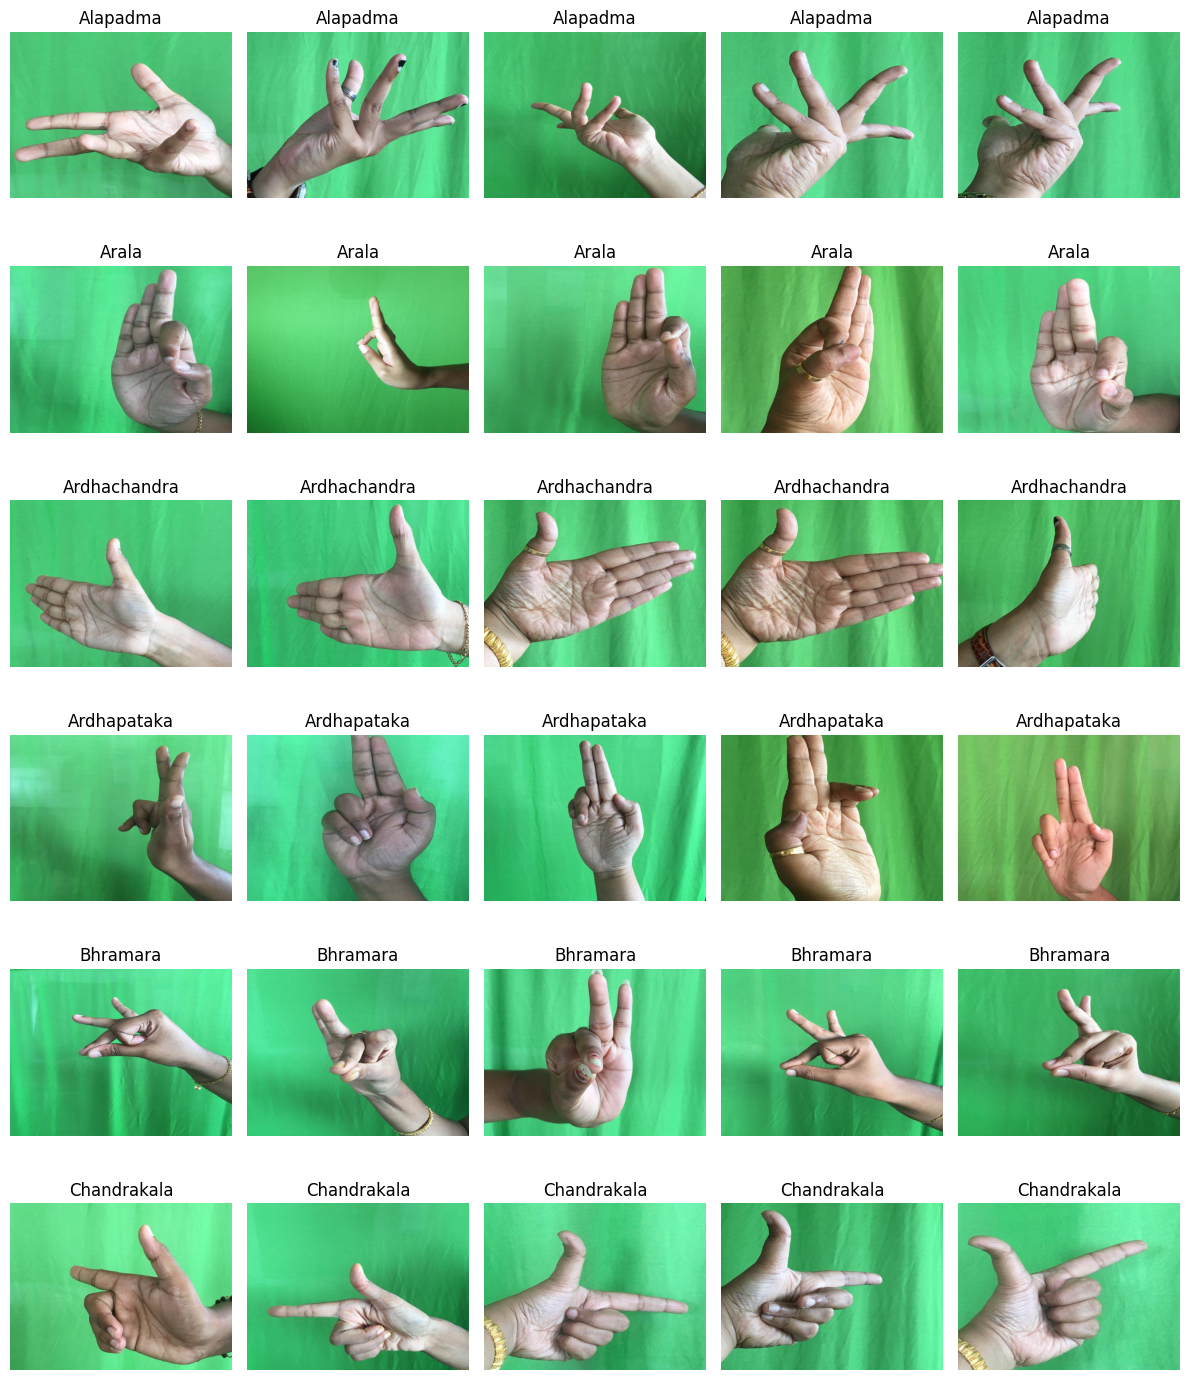

In [5]:
import matplotlib.pyplot as plt
NUM_EXAMPLES = 5
IMAGES_PATH = str(DATASET_DIR)
classes_to_show = class_dirs[: min(6, len(class_dirs))]
fig, axes = plt.subplots(len(classes_to_show), NUM_EXAMPLES, figsize=(NUM_EXAMPLES * 2.4, len(classes_to_show) * 2.4))

if len(classes_to_show) == 1:
    axes = [axes]

for row_index, class_dir in enumerate(classes_to_show):
    example_paths = sorted(path for path in class_dir.iterdir() if path.is_file())[:NUM_EXAMPLES]
    for col_index, image_path in enumerate(example_paths):
        axes[row_index][col_index].imshow(plt.imread(image_path))
        axes[row_index][col_index].set_title(class_dir.name)
        axes[row_index][col_index].axis("off")
    for col_index in range(len(example_paths), NUM_EXAMPLES):
        axes[row_index][col_index].axis("off")

plt.tight_layout()
plt.show()

## Making a New Model



In [3]:
# Import the necessary modules.
from mediapipe_model_maker import gesture_recognizer

ModuleNotFoundError: No module named 'pkg_resources'

In [ ]:
# Load the hasta image dataset.
data = gesture_recognizer.Dataset.from_folder(
    dirname=IMAGES_PATH,
    hparams=gesture_recognizer.HandDataPreprocessingParams()
)

# Split into training, validation, and test datasets.
train_data, rest_data = data.split(0.8)
validation_data, test_data = rest_data.split(0.5)

print("Created train, validation, and test splits from the hasta dataset.")

In [ ]:
# Train the model
hparams = gesture_recognizer.HParams(export_dir="hasta_classifier_model")
options = gesture_recognizer.GestureRecognizerOptions(hparams=hparams)
model = gesture_recognizer.GestureRecognizer.create(
    train_data=train_data,
    validation_data=validation_data,
    options=options
)

In [ ]:
loss, acc = model.evaluate(test_data, batch_size=1)
print(f"Test loss:{loss}, Test accuracy:{acc}")

In [ ]:
# Export the model bundle.
import shutil

model.export_model()

# Copy the exported bundle to a descriptive top-level filename.
exported_model_path = Path("hasta_classifier_model/gesture_recognizer.task")
final_model_path = Path("hasta_classifier.task")
shutil.copy2(exported_model_path, final_model_path)
print(f"Saved model bundle to {final_model_path.resolve()}")

In [ ]:
assert final_model_path.exists(), f"Model file not found: {final_model_path.resolve()}"
final_model_path

In [ ]:
example_image_path = sorted(class_dirs[-1].glob("*"))[0]
plt.figure(figsize=(4, 4))
plt.imshow(plt.imread(example_image_path))
plt.title(f"Inference example: {example_image_path.parent.name}")
plt.axis("off")
plt.show()

In [ ]:
# Imports neccessary modules.
import os
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Create a GestureRecognizer object.
model_path = os.path.abspath("hasta_classifier.task")
recognizer = vision.GestureRecognizer.create_from_model_path(model_path)

# Load the input image.
image = mp.Image.create_from_file(str(example_image_path))

# Run gesture recognition.
recognition_result = recognizer.recognize(image)

# Display the most likely gesture.
top_gesture = recognition_result.gestures[0][0]
print(f"Expected label: {example_image_path.parent.name}")
print(f"Gesture recognized: {top_gesture.category_name} ({top_gesture.score})")